In [2]:
import pandas as pd

df = pd.read_csv("./cleaned_data/train.csv")


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10524 entries, 0 to 10523
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        10524 non-null  int64  
 1   nHBDon            10524 non-null  float64
 2   nHBAcc            10524 non-null  float64
 3   nRing             10524 non-null  float64
 4   MW                10524 non-null  float64
 5   TopoPSA(NO)       10524 non-null  float64
 6   SLogP             10524 non-null  float64
 7   nAromAtom         10524 non-null  float64
 8   nRot              10524 non-null  float64
 9   Kier1             10524 non-null  float64
 10  Kier2             10524 non-null  object 
 11  Kier3             10524 non-null  object 
 12  BalabanJ          10524 non-null  float64
 13  Zagreb1           10524 non-null  float64
 14  BertzCT           10524 non-null  float64
 15  Name              10524 non-null  object 
 16  SMILES_x          10524 non-null  object

In [5]:
df = df.drop(columns=['Unnamed: 0', 'SLogP'])

KeyError: "['Unnamed: 0', 'SLogP'] not found in axis"

In [4]:
df.head()

,nHBDon,nHBAcc,nRing,MW,TopoPSA(NO),nAromAtom,nRot,Kier1,Kier2,Kier3,...,Name,SMILES_x,ChemID,CAS,SMILES_y,MPID,Canonical_QSARr,InChI_Code_QSARr,InChI Key_QSARr,LogP
0,0.0,0.0,2.0,136.125201,0.00,0.0,0.0,6.694215,1.7777777777777777,0.7168,...,(+)-Camphene,[H]C([H])=C1C2([H])C([H])([H])C([H])([H])C([H]...,104811,5794-03-6,[H]C([H])=C1C2([H])C([H])([H])C([H])([H])C([H]...,9266,CC1(C)C2CC(CC2)C1=C,"InChI=1S/C10H16/c1-7-8-4-5-9(6-8)10(7,2)3/h8-9...",CRPUJAZIXJMDBK-UHFFFAOYSA-N,4.22
1,1.0,1.0,2.0,154.135765,20.23,0.0,0.0,7.638889,1.836734693877551,0.760998810939358,...,(+)-Fenchol,[H]OC1([H])C2(C([H])([H])[H])C([H])([H])C([H])...,103768,2217-02-9,[H]OC1([H])C2(C([H])([H])[H])C([H])([H])C([H])...,8290,CC1(C)C(O)C2(C)CC1CC2,"InChI=1S/C10H18O/c1-9(2)7-4-5-10(3,6-7)8(9)11/...",IAIHUHQCLTYTSF-UHFFFAOYSA-N,3.17
2,0.0,1.0,1.0,154.135765,17.07,0.0,1.0,9.090909,3.6,2.2145328719723185,...,(-)-Menthone,[H]C([H])([H])C1([H])C([H])([H])C(=O)C([H])(C(...,105489,14073-97-3,[H]C([H])([H])C1([H])C([H])([H])C(=O)C([H])(C(...,9869,CC(C)C1CCC(C)CC1=O,InChI=1S/C10H18O/c1-7(2)9-5-4-8(3)6-10(9)11/h7...,NFLGAXVYCFJBMK-UHFFFAOYSA-N,3.05
3,4.0,4.0,1.0,169.073893,86.71,6.0,2.0,10.083333,4.296875,2.4930747922437675,...,(-)-NORADRENALINE,[H]OC1=C(O[H])C([H])=C(C([H])(O[H])C([H])([H])...,100054,51-41-2,[H]OC1=C(O[H])C([H])=C(C([H])(O[H])C([H])([H])...,4725,NCC(O)c1cc(O)c(O)cc1,InChI=1S/C8H11NO3/c9-4-8(12)5-1-2-6(10)7(11)3-...,SFLSHLFXELFNJZ-UHFFFAOYSA-N,-1.24
4,0.0,0.0,1.0,246.234751,0.00,6.0,10.0,16.055556,10.88,7.258979206049149,...,(1-PROPYLNONYL)BENZENE,[H]C1=C([H])C([H])=C(C([H])(C([H])([H])C([H])(...,104023,2719-64-4,[H]C1=C([H])C([H])=C(C([H])(C([H])([H])C([H])(...,8526,CCCCCCCCC(CCC)c1ccccc1,InChI=1S/C18H30/c1-3-5-6-7-8-10-14-17(13-4-2)1...,RHDHXBLZBVAPTL-UHFFFAOYSA-N,8.07


In [11]:
median_val = df["TopoPSA(NO)"].median()

low_group  = df[df["TopoPSA(NO)"] <  median_val]["LogP"]
high_group = df[df["TopoPSA(NO)"] >= median_val]["LogP"]

In [31]:
import numpy as np
from scipy.stats import ttest_ind

# 중앙값 기준으로 그륩 나누기
median_val = df["TopoPSA(NO)"].median()

low_group  = df[df["TopoPSA(NO)"] <  median_val]["LogP"]
high_group = df[df["TopoPSA(NO)"] >= median_val]["LogP"]

t_stat, p_val = ttest_ind(low_group, high_group, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_val)

# 검정
alpha = 0.05
if p_val < alpha:
    print("결론: 귀무가설 기각 → 두 집단의 LogP 평균은 통계적으로 유의하게 다름.")
else:
    print("결론: 귀무가설 채택 → 두 집단의 LogP 평균 차이는 통계적으로 유의하지 않음.")


t-statistic: 33.72852292158045
p-value: 9.167831024202118e-237
결론: 귀무가설 기각 → 두 집단의 LogP 평균은 통계적으로 유의하게 다름.


In [33]:
mean1 = low_group.mean()
mean2 = high_group.mean()
std1 = low_group.std()
std2 = high_group.std()

n1 = len(low_group)
n2 = len(high_group)

# pooled std
s_pooled = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))
cohens_d = (mean1 - mean2) / s_pooled

print("Cohen's d:", cohens_d)

Cohen's d: 0.6576150483920334


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10524 entries, 0 to 10523
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   nHBDon            10524 non-null  float64
 1   nHBAcc            10524 non-null  float64
 2   nRing             10524 non-null  float64
 3   MW                10524 non-null  float64
 4   TopoPSA(NO)       10524 non-null  float64
 5   nAromAtom         10524 non-null  float64
 6   nRot              10524 non-null  float64
 7   Kier1             10524 non-null  float64
 8   Kier2             10524 non-null  object 
 9   Kier3             10524 non-null  object 
 10  BalabanJ          10524 non-null  float64
 11  Zagreb1           10524 non-null  float64
 12  BertzCT           10524 non-null  float64
 13  Name              10524 non-null  object 
 14  SMILES_x          10524 non-null  object 
 15  ChemID            10524 non-null  int64  
 16  CAS               10524 non-null  object

In [ ]:
median_val = df["MW"].median()

low_group  = df[df["MW"] <  median_val]["LogP"]
high_group = df[df["MW"] >= median_val]["LogP"]



# 중앙값 기준으로 그륩 나누기
median_val = df["MW"].median()

low_group  = df[df["MW"] <  median_val]["LogP"]
high_group = df[df["MW"] >= median_val]["LogP"]

t_stat, p_val = ttest_ind(low_group, high_group, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_val)

# 검정
alpha = 0.05
if p_val < alpha:
    print("결론: 귀무가설 기각 → 두 집단의 LogP 평균은 통계적으로 유의하게 다름.")
else:
    print("결론: 귀무가설 채택 → 두 집단의 LogP 평균 차이는 통계적으로 유의하지 않음.")





t-statistic: -30.392443265625072
p-value: 7.08318125669786e-194
결론: 귀무가설 기각 → 두 집단의 LogP 평균은 통계적으로 유의하게 다름.


/tmp/ipykernel_2273/2480082406.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low_group, high_group], labels=["Low MW", "High MW"])


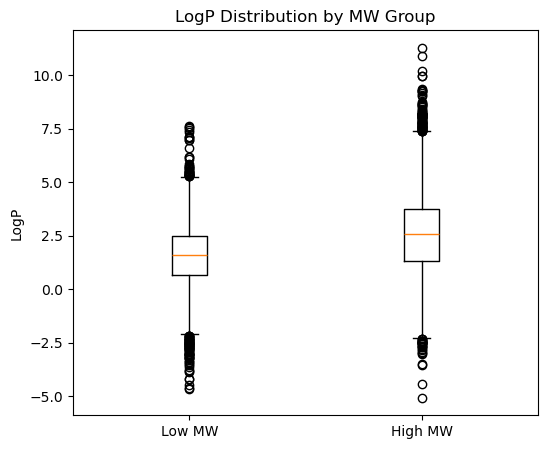

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.boxplot([low_group, high_group], labels=["Low MW", "High MW"])
plt.ylabel("LogP")
plt.title("LogP Distribution by MW Group")
plt.show()

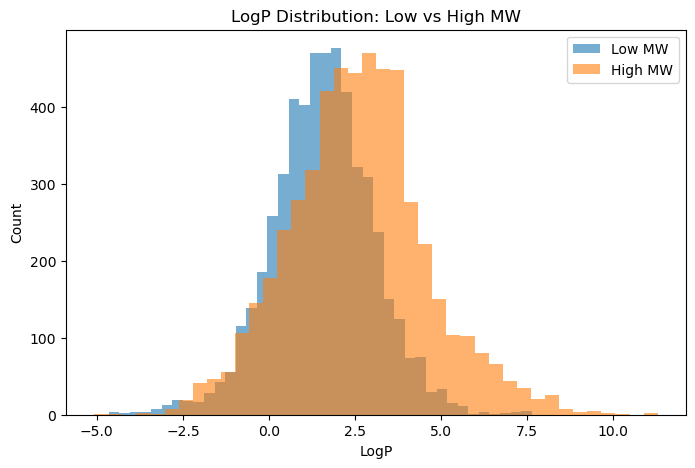

In [17]:
plt.figure(figsize=(8,5))
plt.hist(low_group, bins=40, alpha=0.6, label="Low MW")
plt.hist(high_group, bins=40, alpha=0.6, label="High MW")
plt.xlabel("LogP")
plt.ylabel("Count")
plt.title("LogP Distribution: Low vs High MW")
plt.legend()
plt.show()

In [20]:
print("Low MW mean:", low_group.mean())
print("High MW mean:", high_group.mean())
print("Difference:", high_group.mean() - low_group.mean())


Low MW mean: 1.5550315589353612
High MW mean: 2.5942325227963527
Difference: 1.0392009638609916


In [21]:
import numpy as np

mean1 = low_group.mean()
mean2 = high_group.mean()
std1 = low_group.std()
std2 = high_group.std()

n1 = len(low_group)
n2 = len(high_group)

# pooled std
s_pooled = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))
cohens_d = (mean2 - mean1) / s_pooled

print("Cohen's d:", cohens_d)


Cohen's d: 0.5924569598207606


In [29]:
sample_df = df.sample(n=100, random_state=42)

median_val = sample_df["MW"].median()

low_group  = sample_df[sample_df["MW"] <  median_val]["LogP"]
high_group = sample_df[sample_df["MW"] >= median_val]["LogP"]

t_stat, p_val = ttest_ind(low_group, high_group, equal_var=False)

alpha = 0.05
if p_val < alpha:
    print("결론: 귀무가설 기각 → 두 집단의 LogP 평균은 통계적으로 유의하게 다름.")
else:
    print("결론: 귀무가설 채택 → 두 집단의 LogP 평균 차이는 통계적으로 유의하지 않음.")


print("t-statistic:", t_stat)
print("p-value:", p_val)

print("\nLow MW mean:", low_group.mean())
print("High MW mean:", high_group.mean())
print("Difference:", high_group.mean() - low_group.mean())

결론: 귀무가설 채택 → 두 집단의 LogP 평균 차이는 통계적으로 유의하지 않음.
t-statistic: -1.9466779091909385
p-value: 0.05487267938458951

Low MW mean: 1.7152000000000003
High MW mean: 2.3908
Difference: 0.6755999999999998


In [26]:
sample_df = df.sample(n=100, random_state=42)

median_val = sample_df["TopoPSA(NO)"].median()

low_group  = sample_df[sample_df["TopoPSA(NO)"] <  median_val]["LogP"]
high_group = sample_df[sample_df["TopoPSA(NO)"] >= median_val]["LogP"]

t_stat, p_val = ttest_ind(low_group, high_group, equal_var=False)


alpha = 0.05
if p_val < alpha:
    print("결론: 귀무가설 기각 → 두 집단의 LogP 평균은 통계적으로 유의하게 다름.")
else:
    print("결론: 귀무가설 채택 → 두 집단의 LogP 평균 차이는 통계적으로 유의하지 않음.")


print("t-statistic:", t_stat)
print("p-value:", p_val)

print("\nLow TopoPSA(NO) mean:", low_group.mean())
print("High TopoPSA(NO) mean:", high_group.mean())
print("Difference:", high_group.mean() - low_group.mean())

결론: 귀무가설 기각 → 두 집단의 LogP 평균은 통계적으로 유의하게 다름.
t-statistic: 4.313968588403395
p-value: 3.899155662687745e-05

Low TopoPSA(NO) mean: 2.7523999999999997
High TopoPSA(NO) mean: 1.3536000000000001
Difference: -1.3987999999999996


In [35]:
import statsmodels.api as sm

def backward_elimination(df, target, features, alpha=0.05):
    X = df[features].copy()
    y = df[target]

    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit() # 선형회귀 돌리기기

    while True:
        # 현재 모델의 p-values
        pvals = model.pvalues.drop("const", errors="ignore")

        # 가장 큰 p-value 찾기
        max_p = pvals.max()
        worst_feature = pvals.idxmax()

        # 제거 기준보다 크면 제거
        if max_p > alpha:
            print(f"[제거] {worst_feature} (p={max_p:.4f})")
            features.remove(worst_feature)

            # 새 모델 적합
            X = sm.add_constant(df[features])
            model = sm.OLS(y, X).fit()
        else:
            break

    print("\n[최종 남은 변수]\n", features)
    return model, features


feature_cols = [
    "nHBDon", "nHBAcc", "nRing", "MW", "TopoPSA(NO)",
     "nAromAtom", "nRot", "Kier1",
    "BalabanJ", "Zagreb1", "BertzCT"
]

model, selected_features = backward_elimination(
    df,
    target="LogP",
    features=feature_cols.copy(), 
    alpha=0.05
)

print(model.summary())
print("최종 선택된 변수:", selected_features)



[최종 남은 변수]
 ['nHBDon', 'nHBAcc', 'nRing', 'MW', 'TopoPSA(NO)', 'nAromAtom', 'nRot', 'Kier1', 'BalabanJ', 'Zagreb1', 'BertzCT']
                            OLS Regression Results                            
Dep. Variable:                   LogP   R-squared:                       0.576
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     1296.
Date:                Tue, 25 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:00:07   Log-Likelihood:                -16778.
No. Observations:               10524   AIC:                         3.358e+04
Df Residuals:                   10512   BIC:                         3.367e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
--

/home/junsoo/miniconda3/envs/mordred/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


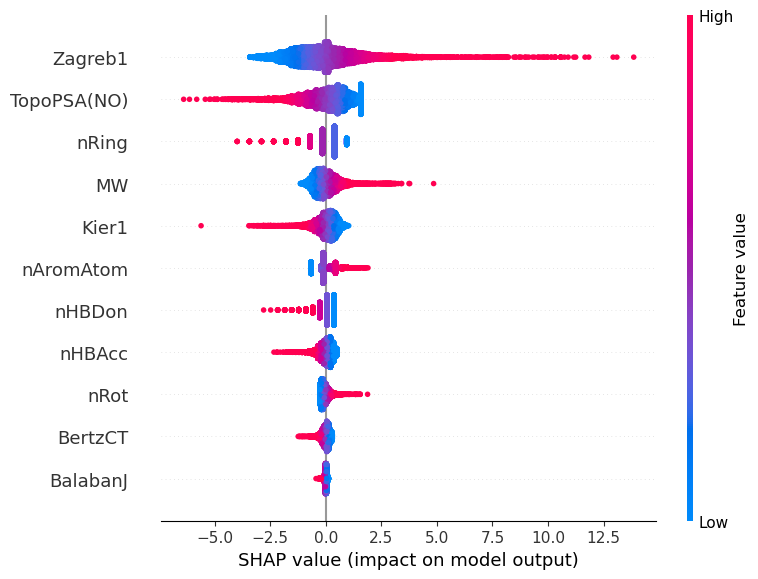

In [37]:
import shap

# X, y 준비
X = df[selected_features]
y = df["LogP"]

# 선형 모델 (sklearn 버전)
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X, y)

explainer = shap.Explainer(model, X)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10524 entries, 0 to 10523
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   nHBDon            10524 non-null  float64
 1   nHBAcc            10524 non-null  float64
 2   nRing             10524 non-null  float64
 3   MW                10524 non-null  float64
 4   TopoPSA(NO)       10524 non-null  float64
 5   nAromAtom         10524 non-null  float64
 6   nRot              10524 non-null  float64
 7   Kier1             10524 non-null  float64
 8   Kier2             10524 non-null  object 
 9   Kier3             10524 non-null  object 
 10  BalabanJ          10524 non-null  float64
 11  Zagreb1           10524 non-null  float64
 12  BertzCT           10524 non-null  float64
 13  Name              10524 non-null  object 
 14  SMILES_x          10524 non-null  object 
 15  ChemID            10524 non-null  int64  
 16  CAS               10524 non-null  object

In [7]:
df.head()

,nHBDon,nHBAcc,nRing,MW,TopoPSA(NO),nAromAtom,nRot,Kier1,Kier2,Kier3,...,Name,SMILES_x,ChemID,CAS,SMILES_y,MPID,Canonical_QSARr,InChI_Code_QSARr,InChI Key_QSARr,LogP
0,0.0,0.0,2.0,136.125201,0.00,0.0,0.0,6.694215,1.7777777777777777,0.7168,...,(+)-Camphene,[H]C([H])=C1C2([H])C([H])([H])C([H])([H])C([H]...,104811,5794-03-6,[H]C([H])=C1C2([H])C([H])([H])C([H])([H])C([H]...,9266,CC1(C)C2CC(CC2)C1=C,"InChI=1S/C10H16/c1-7-8-4-5-9(6-8)10(7,2)3/h8-9...",CRPUJAZIXJMDBK-UHFFFAOYSA-N,4.22
1,1.0,1.0,2.0,154.135765,20.23,0.0,0.0,7.638889,1.836734693877551,0.760998810939358,...,(+)-Fenchol,[H]OC1([H])C2(C([H])([H])[H])C([H])([H])C([H])...,103768,2217-02-9,[H]OC1([H])C2(C([H])([H])[H])C([H])([H])C([H])...,8290,CC1(C)C(O)C2(C)CC1CC2,"InChI=1S/C10H18O/c1-9(2)7-4-5-10(3,6-7)8(9)11/...",IAIHUHQCLTYTSF-UHFFFAOYSA-N,3.17
2,0.0,1.0,1.0,154.135765,17.07,0.0,1.0,9.090909,3.6,2.2145328719723185,...,(-)-Menthone,[H]C([H])([H])C1([H])C([H])([H])C(=O)C([H])(C(...,105489,14073-97-3,[H]C([H])([H])C1([H])C([H])([H])C(=O)C([H])(C(...,9869,CC(C)C1CCC(C)CC1=O,InChI=1S/C10H18O/c1-7(2)9-5-4-8(3)6-10(9)11/h7...,NFLGAXVYCFJBMK-UHFFFAOYSA-N,3.05
3,4.0,4.0,1.0,169.073893,86.71,6.0,2.0,10.083333,4.296875,2.4930747922437675,...,(-)-NORADRENALINE,[H]OC1=C(O[H])C([H])=C(C([H])(O[H])C([H])([H])...,100054,51-41-2,[H]OC1=C(O[H])C([H])=C(C([H])(O[H])C([H])([H])...,4725,NCC(O)c1cc(O)c(O)cc1,InChI=1S/C8H11NO3/c9-4-8(12)5-1-2-6(10)7(11)3-...,SFLSHLFXELFNJZ-UHFFFAOYSA-N,-1.24
4,0.0,0.0,1.0,246.234751,0.00,6.0,10.0,16.055556,10.88,7.258979206049149,...,(1-PROPYLNONYL)BENZENE,[H]C1=C([H])C([H])=C(C([H])(C([H])([H])C([H])(...,104023,2719-64-4,[H]C1=C([H])C([H])=C(C([H])(C([H])([H])C([H])(...,8526,CCCCCCCCC(CCC)c1ccccc1,InChI=1S/C18H30/c1-3-5-6-7-8-10-14-17(13-4-2)1...,RHDHXBLZBVAPTL-UHFFFAOYSA-N,8.07


In [9]:
# from sklearn.model_selection import train_test_split
# X, _ = train_test_split(X = df, test_size=0.2, stra .. )



In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10524 entries, 0 to 10523
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   nHBDon            10524 non-null  float64
 1   nHBAcc            10524 non-null  float64
 2   nRing             10524 non-null  float64
 3   MW                10524 non-null  float64
 4   TopoPSA(NO)       10524 non-null  float64
 5   nAromAtom         10524 non-null  float64
 6   nRot              10524 non-null  float64
 7   Kier1             10524 non-null  float64
 8   Kier2             10524 non-null  object 
 9   Kier3             10524 non-null  object 
 10  BalabanJ          10524 non-null  float64
 11  Zagreb1           10524 non-null  float64
 12  BertzCT           10524 non-null  float64
 13  Name              10524 non-null  object 
 14  SMILES_x          10524 non-null  object 
 15  ChemID            10524 non-null  int64  
 16  CAS               10524 non-null  object

In [12]:
df.head()

,nHBDon,nHBAcc,nRing,MW,TopoPSA(NO),nAromAtom,nRot,Kier1,Kier2,Kier3,...,Name,SMILES_x,ChemID,CAS,SMILES_y,MPID,Canonical_QSARr,InChI_Code_QSARr,InChI Key_QSARr,LogP
0,0.0,0.0,2.0,136.125201,0.00,0.0,0.0,6.694215,1.7777777777777777,0.7168,...,(+)-Camphene,[H]C([H])=C1C2([H])C([H])([H])C([H])([H])C([H]...,104811,5794-03-6,[H]C([H])=C1C2([H])C([H])([H])C([H])([H])C([H]...,9266,CC1(C)C2CC(CC2)C1=C,"InChI=1S/C10H16/c1-7-8-4-5-9(6-8)10(7,2)3/h8-9...",CRPUJAZIXJMDBK-UHFFFAOYSA-N,4.22
1,1.0,1.0,2.0,154.135765,20.23,0.0,0.0,7.638889,1.836734693877551,0.760998810939358,...,(+)-Fenchol,[H]OC1([H])C2(C([H])([H])[H])C([H])([H])C([H])...,103768,2217-02-9,[H]OC1([H])C2(C([H])([H])[H])C([H])([H])C([H])...,8290,CC1(C)C(O)C2(C)CC1CC2,"InChI=1S/C10H18O/c1-9(2)7-4-5-10(3,6-7)8(9)11/...",IAIHUHQCLTYTSF-UHFFFAOYSA-N,3.17
2,0.0,1.0,1.0,154.135765,17.07,0.0,1.0,9.090909,3.6,2.2145328719723185,...,(-)-Menthone,[H]C([H])([H])C1([H])C([H])([H])C(=O)C([H])(C(...,105489,14073-97-3,[H]C([H])([H])C1([H])C([H])([H])C(=O)C([H])(C(...,9869,CC(C)C1CCC(C)CC1=O,InChI=1S/C10H18O/c1-7(2)9-5-4-8(3)6-10(9)11/h7...,NFLGAXVYCFJBMK-UHFFFAOYSA-N,3.05
3,4.0,4.0,1.0,169.073893,86.71,6.0,2.0,10.083333,4.296875,2.4930747922437675,...,(-)-NORADRENALINE,[H]OC1=C(O[H])C([H])=C(C([H])(O[H])C([H])([H])...,100054,51-41-2,[H]OC1=C(O[H])C([H])=C(C([H])(O[H])C([H])([H])...,4725,NCC(O)c1cc(O)c(O)cc1,InChI=1S/C8H11NO3/c9-4-8(12)5-1-2-6(10)7(11)3-...,SFLSHLFXELFNJZ-UHFFFAOYSA-N,-1.24
4,0.0,0.0,1.0,246.234751,0.00,6.0,10.0,16.055556,10.88,7.258979206049149,...,(1-PROPYLNONYL)BENZENE,[H]C1=C([H])C([H])=C(C([H])(C([H])([H])C([H])(...,104023,2719-64-4,[H]C1=C([H])C([H])=C(C([H])(C([H])([H])C([H])(...,8526,CCCCCCCCC(CCC)c1ccccc1,InChI=1S/C18H30/c1-3-5-6-7-8-10-14-17(13-4-2)1...,RHDHXBLZBVAPTL-UHFFFAOYSA-N,8.07


In [ ]:
!pip install scikit-learn

# Regression Task 


# Linear Regression : 
# RandomForest : 공부하셔서 돌려보시고
# XGBoost | LightGBM : Gradient boosting model
# 트리 기반 모델인데, 오차 자체를 학습해서 오차를 예측하는 또 다른 모델을 만든다. 

# 정답. 예측한 값 정답-예측 = 오차  , 오차를 예측한다면?
# 예측한 값 + 예측한 오차 = 정답 



In [13]:
# 모델 선정
# 돌려야되는데

# 무조건 numerical feature : 숫자 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10524 entries, 0 to 10523
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   nHBDon            10524 non-null  float64
 1   nHBAcc            10524 non-null  float64
 2   nRing             10524 non-null  float64
 3   MW                10524 non-null  float64
 4   TopoPSA(NO)       10524 non-null  float64
 5   nAromAtom         10524 non-null  float64
 6   nRot              10524 non-null  float64
 7   Kier1             10524 non-null  float64
 8   Kier2             10524 non-null  object 
 9   Kier3             10524 non-null  object 
 10  BalabanJ          10524 non-null  float64
 11  Zagreb1           10524 non-null  float64
 12  BertzCT           10524 non-null  float64
 13  Name              10524 non-null  object 
 14  SMILES_x          10524 non-null  object 
 15  ChemID            10524 non-null  int64  
 16  CAS               10524 non-null  object

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [ ]:
# Sclaer 를 돌릴건지 

from sklearn.preprocessing import StandardScaler, MinMaxScaler

ss = StandardScaler()


# 돌릴때 test 셋은 좀 다르게 돌려야된다. -> fit(train) | fit_transfrom (test)


In [ ]:
train 넣을 때
model에 넣어주는 hyperparameter 

여러 조합이 존재

max_depth = 50 , 100, None


SyntaxError: invalid syntax (3387996451.py, line 1)

In [ ]:
from sklearn import GridSearchCV

